In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
bw_data=pd.read_csv("bollywood.csv")

In [4]:
bw_data

,SlNo,Release Date,MovieName,ReleaseTime,Genre,Budget,BoxOfficeCollection,YoutubeViews,YoutubeLikes,YoutubeDislikes
0,1,18-Apr-14,2 States,LW,Romance,36,104.00,8576361,26622,2527
1,2,4-Jan-13,Table No. 21,N,Thriller,10,12.00,1087320,1129,137
2,3,18-Jul-14,Amit Sahni Ki List,N,Comedy,10,4.00,572336,586,54
3,4,4-Jan-13,Rajdhani Express,N,Drama,7,0.35,42626,86,19
4,5,4-Jul-14,Bobby Jasoos,N,Comedy,18,10.80,3113427,4512,1224
...,...,...,...,...,...,...,...,...,...,...
144,145,27-Feb-15,Dum Laga Ke Haisha,N,Comedy,15,30.00,3250917,8185,615
145,146,13-Mar-15,NH10,N,Thriller,13,32.10,5592977,15464,1513
146,147,20-Mar-15,Dilliwali Zaalim Girlfriend,N,Comedy,32,12.00,2316047,4289,807
147,148,20-Mar-15,Hunterrr,N,Comedy,5,11.89,4674795,3706,762


In [5]:
bw_data.columns

Index(['SlNo', 'Release Date', 'MovieName', 'ReleaseTime', 'Genre', 'Budget',
       'BoxOfficeCollection', 'YoutubeViews', 'YoutubeLikes',
       'YoutubeDislikes'],
      dtype='str')

In [6]:
#how many records are in the dataset? metadata info
bw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SlNo                 149 non-null    int64  
 1   Release Date         149 non-null    str    
 2   MovieName            149 non-null    str    
 3   ReleaseTime          149 non-null    str    
 4   Genre                149 non-null    str    
 5   Budget               149 non-null    int64  
 6   BoxOfficeCollection  149 non-null    float64
 7   YoutubeViews         149 non-null    int64  
 8   YoutubeLikes         149 non-null    int64  
 9   YoutubeDislikes      149 non-null    int64  
dtypes: float64(1), int64(5), str(4)
memory usage: 11.8 KB


In [12]:
bw_data.Genre.value_counts().sort_values(ascending=False) #no. of movies in each genre and sort it in descending

Genre
Comedy       36
 Drama       35
Thriller     26
Romance      25
Action       21
Thriller      3
Action        3
Name: count, dtype: int64

In [13]:
pd.crosstab(bw_data['Genre'],bw_data['ReleaseTime'])

ReleaseTime,FS,HS,LW,N
Genre,,,,
Drama,4,6,1,24
Action,3,3,3,12
Action,0,0,0,3
Comedy,3,5,5,23
Romance,3,3,4,15
Thriller,4,1,1,20
Thriller,0,0,1,2


In [21]:
bw_data['month'] = pd.to_datetime(
    bw_data['Release Date'],
    format='%d-%b-%y'
).dt.month
bw_data['month'].value_counts().sort_values(ascending=False) #which month the max movies were released

month
1     20
3     19
5     18
7     16
2     16
4     11
9     10
6     10
11    10
10     9
8      8
12     2
Name: count, dtype: int64

In [37]:
bw_data[bw_data['Budget'] >= 25]['month'].value_counts().sort_values(ascending=False)

month
2     9
1     8
3     7
8     7
11    6
7     6
9     5
6     5
4     4
10    4
5     3
12    2
Name: count, dtype: int64

In [42]:
bw_data['roi']=bw_data.apply(
    lambda rec: (rec["BoxOfficeCollection"] - rec["Budget"])/ rec["Budget"],
    axis=1
)
bw_data[['MovieName', 'roi']].sort_values(
    'roi',
    ascending=False
)[:10]

,MovieName,roi
64,Aashiqui 2,8.166667
89,PK,7.647059
132,Grand Masti,7.514286
135,The Lunchbox,7.500000
87,Fukrey,6.240000
58,Mary Kom,5.933333
128,Shahid,5.666667
37,Humpty Sharma Ki Dulhania,5.500000
101,Bhaag Milkha Bhaag,4.466667
115,Chennai Express,4.266667


In [43]:
bw_data[['ReleaseTime', 'roi']].sort_values(
    'roi',
    ascending=False
)[:10]

,ReleaseTime,roi
64,N,8.166667
89,HS,7.647059
132,LW,7.514286
135,N,7.500000
87,N,6.240000
58,N,5.933333
128,FS,5.666667
37,N,5.500000
101,N,4.466667
115,FS,4.266667


In [44]:
avg_roi = (
    bw_data.groupby('ReleaseTime')['roi']
    .mean()
    .sort_values(ascending=False)
)

avg_roi

ReleaseTime
LW    1.127205
FS    0.973853
HS    0.850867
N     0.657722
Name: roi, dtype: float64

<Axes: xlabel='Budget', ylabel='Count'>

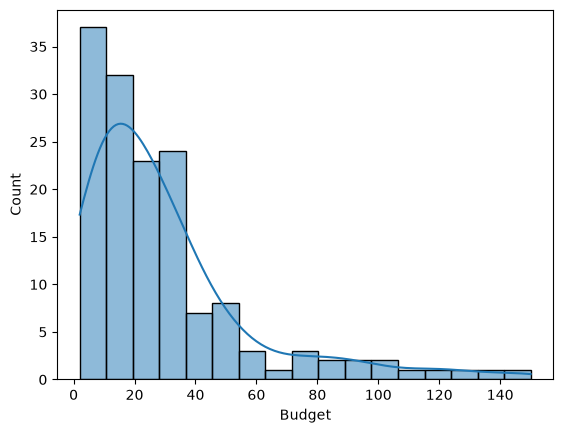

In [52]:
sns.histplot(bw_data['Budget'],kde=True)

In [63]:
avg_roi_genre = (
    bw_data.groupby('Genre')['roi']
    .mean()
    .sort_values(ascending=False)
)

avg_roi_genre

Genre
 Drama       1.357455
Romance      1.003218
Comedy       0.788394
Action       0.431054
Thriller     0.421667
Thriller     0.169578
Action      -0.602028
Name: roi, dtype: float64

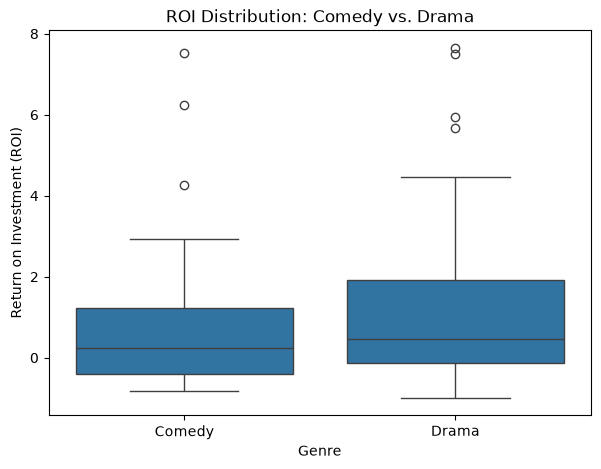

Genre
 Drama     0.466667
Comedy     0.236061
Name: roi, dtype: float64


In [78]:
filtered = bw_data[
    bw_data['Genre'].str.strip().str.lower().isin(['comedy', 'drama'])
]

plt.figure(figsize=(7, 5))

sns.boxplot(
    x='Genre',
    y='roi',
    data=filtered
)

plt.title('ROI Distribution: Comedy vs. Drama')
plt.ylabel('Return on Investment (ROI)')

plt.show()

print(
    filtered.groupby('Genre')['roi']
    .median()
)

<Axes: >

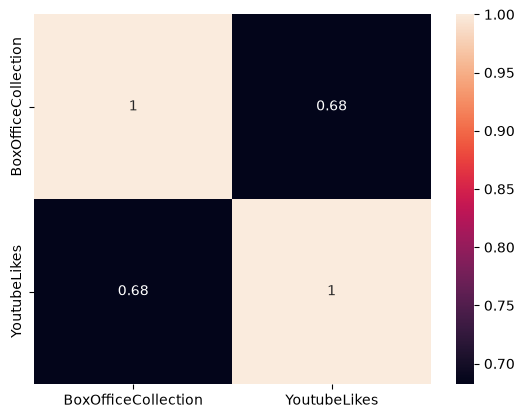

In [82]:
features=['BoxOfficeCollection','YoutubeLikes']
sns.heatmap(bw_data[features].corr(),annot=True)

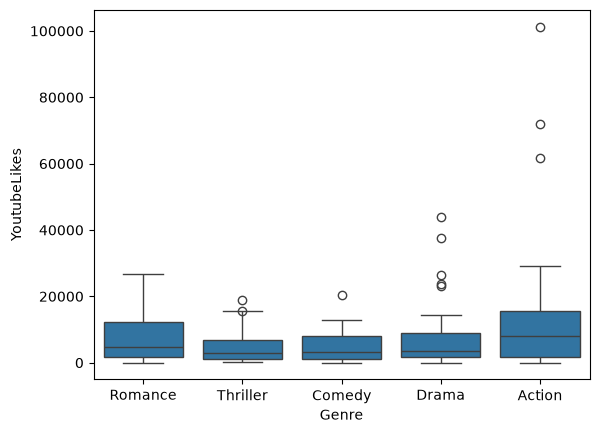

Genre
Action      7951.0
Comedy      3365.0
Drama       3656.0
Romance     4853.0
Thriller    2974.0
Name: YoutubeLikes, dtype: float64


In [90]:
bw_data['Genre'] = bw_data['Genre'].str.strip()
sns.boxplot(
    x='Genre',
    y='YoutubeLikes',
    data=bw_data
)
plt.show()
print(
    bw_data.groupby('Genre')['YoutubeLikes']
    .median()
)

<Axes: >

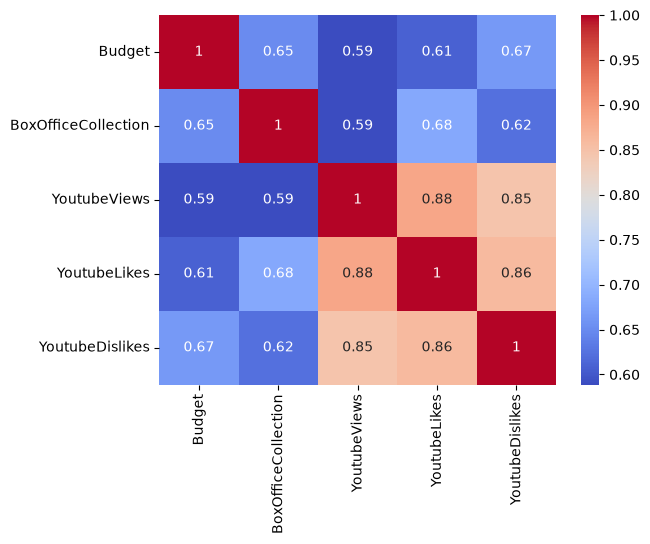

In [98]:
features=['Budget','BoxOfficeCollection','YoutubeViews','YoutubeLikes','YoutubeDislikes']
sns.heatmap(bw_data[features].corr(),annot=True, cmap="Blues")